# EDA vitaminado · el precio y su contexto  *(v2 — 28-ago-2026)*

Continuación de `02_eda_bronze.ipynb`. Aquel notebook contrasta decisiones de fuente y calidad
sobre las seis tablas del bronce; éste incorpora las que faltaban — y sobre todo **el target** —
para responder preguntas que aquél no puede.

**Mismo formato:** contexto → decisión → evidencia → consecuencia. Mismos principios: no se
imputa nada, los `NaN` son información, y una correlación alta no autoriza una feature.

## Qué cambia respecto de la v1

La radiografía de la base del 27-ago cambió tres supuestos sobre los que estaba escrita:

1. **Los nombres de columna ya no se adivinan.** `spot_price` trae 14 columnas de precio, con
   España por tres fuentes y **doce países**. El bloque J ya no necesita el dataset externo de
   Ember: el contexto europeo está en la propia base.
2. **H.2 se reescribe.** `ecmwf_forecast_agg` tiene 168 filas: es una ventana móvil de
   inferencia, no histórico. La ablación de "meteorología perfecta" tal como estaba planteada
   no se sostiene, y pasa de análisis a limitación declarada — con una vía abierta.
3. **H.3 pasa de test indirecto a directo.** Ahora sabemos que la tabla de capacidad guarda 24
   filas por día; si esas 24 son idénticas, se puede comprobar D-01 sin rodeos.

Y se añade un bloque nuevo, **N**, sobre dos discontinuidades de ERA5 detectadas al exportar la
tabla: un mes entero sin ráfaga y un cambio de entorno de ingesta en enero de 2025.

## Índice

| Bloque | Pregunta | Estado |
|---|---|---|
| **0** | Carga, integridad y resolución de esquema | — |
| **F** | ¿Cómo es el target? Distribución, colas, censura, regímenes, persistencia | requiere `spot_price` |
| **G** | ¿Qué mueve el precio, y qué de eso existe a las 12:00 de D? | requiere `spot_price` |
| **H** | ¿Cuánto se equivocan las previsiones que sí podemos usar? | requiere `forecast` |
| **I** | ¿El programa aporta algo o es circular? | requiere `esios_pdbc_gen` |
| **J** | El precio español entre sus vecinos, y las commodities | requiere `spot_price` |
| **N** | Discontinuidades de ERA5 | corre con el bronce actual |
| **K** | Cierre: features candidatas con veredicto de fuga | — |

## La regla que atraviesa el notebook

El modelo predice las 24 horas de D+1 **emitiendo a las 12:00 de D**. Ante cualquier correlación
alta la pregunta no es "¿es fuerte?" sino **"¿existía ese dato a las 12:00 de D?"**. Los precios
de los doce países que ahora hay en la base son el ejemplo perfecto: correlacionan
espectacularmente con el español y **ninguno está disponible** para D+1, porque todas las zonas
SDAC se casan a la vez.

---
## 0 · Carga, integridad y resolución de esquema

In [28]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

TZ = "Europe/Madrid"
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
BRONZE_DIR = RAIZ / "data" / "bronze"
print("Raíz:", RAIZ, "| bronze:", BRONZE_DIR.exists())

plt.rcParams.update({"figure.figsize": (11, 4.2), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

APAGON = (pd.Timestamp("2025-04-28", tz="UTC"), pd.Timestamp("2025-05-06 23:00", tz="UTC"))
EXCEPCION = (pd.Timestamp("2022-06-15", tz="UTC"), pd.Timestamp("2023-12-31 23:00", tz="UTC"))
# Fechas de la excepción ibérica PENDIENTES de verificar contra BOE. Condicionan F.5 y G.2.

Raíz: c:\Users\torgi\proyectos\tfm-energia | bronze: True


### 0.1 · Utilidades

`registrar()` es la corrección de un fallo de la v1: allí varios bloques imprimían `OMITIDO`
sin apuntarse en la lista, y el resumen final decía tres omisiones cuando había nueve. La lista
de cierre es justo lo que se lleva a la reunión, así que tiene que estar completa.

In [29]:
OMITIDOS = []

def registrar(motivo):
    '''Único punto de registro: imprime Y anota. Nunca una cosa sin la otra.'''
    OMITIDOS.append(motivo)
    print("OMITIDO --", motivo)
    return False

def pick(df, *cands):
    for c in cands:
        if c is not None and c in df.columns:
            return c
    return None

def necesita(bloque, **cols):
    ausentes = [k for k, v in cols.items() if v is None]
    if ausentes:
        return registrar(f"{bloque}: faltan {ausentes}")
    return True

def a_utc(s):
    return pd.to_datetime(s, utc=True)

def marcar_regimen(d, col="ts_utc"):
    d = d.copy()
    d["regimen"] = np.select(
        [d[col].between(*APAGON), d[col].between(*EXCEPCION)],
        ["apagon", "excepcion_iberica"], default="normal")
    return d

def unir(base, otro, on="ts_utc"):
    '''Merge con validación 1:1 -- el chequeo que habría cazado la duplicación x24.'''
    return base.merge(otro, on=on, how="left", validate="one_to_one")

In [30]:
df = pd.read_parquet(BRONZE_DIR / "bronze_unificado.parquet")
df["ts_utc"] = a_utc(df["ts_utc"])

dup = df["ts_utc"].duplicated().sum()
assert dup == 0, (
    f"{dup:,} filas con ts_utc repetido ({len(df):,} filas para {df['ts_utc'].nunique():,} "
    f"horas, factor {len(df)/df['ts_utc'].nunique():.1f}). Causa conocida: "
    f"esios_capacity_available guarda 24 filas por día y está declarada grain='daily', así que "
    f"el merge por date_local es muchos-a-muchos. Corregir en bronze_config.py y regenerar."
)

df["ts_local"] = df["ts_utc"].dt.tz_convert(TZ)
df["hora"] = df["ts_local"].dt.hour
df["dia"] = df["ts_local"].dt.date
df["mes_p"] = df["ts_local"].dt.to_period("M")
df["anio"] = df["ts_local"].dt.year
df["dow"] = df["ts_local"].dt.dayofweek
df = marcar_regimen(df)
print(f"{len(df):,} horas · {df['ts_utc'].min()} -> {df['ts_utc'].max()}")
print(f"{df.shape[1]} columnas")

58,319 horas · 2019-12-31 23:00:00+00:00 -> 2026-08-26 21:00:00+00:00
103 columnas


C:\Users\torgi\AppData\Local\Temp\ipykernel_50064\3709320920.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["mes_p"] = df["ts_local"].dt.to_period("M")


### 0.2 · Columnas reales

Los nombres salen de la radiografía del 27-ago (`eda/columnas_clave.py`), no de suposiciones.
Cada `pick()` acepta la versión con prefijo del bronce y la cruda, para que el notebook funcione
tanto si `bronze_config.py` ya está actualizado como si se leen los parquets sueltos.

In [31]:
# --- TARGET: tres fuentes españolas (medias 85,84 / 85,84 / 85,85 -> equivalentes, ver F.8)
ES_FUENTES = {n: pick(df, f"spot_{n}", n) for n in ("es_omie", "es_esios", "es_entsoe")}
ES_FUENTES = {k: v for k, v in ES_FUENTES.items() if v}
SPOT = ES_FUENTES.get("es_omie") or (list(ES_FUENTES.values())[0] if ES_FUENTES else None)

# --- Zonas vecinas: TODAS con fuga para D+1 (casación SDAC simultánea a las 12:00)
VECINOS = {}
for iso, etq in [("pt_omie", "Portugal"), ("pt_entsoe", "Portugal (ENTSO-E)"),
                 ("fr_entsoe", "Francia"), ("de_lu_entsoe", "Alemania-Lux"),
                 ("it_nord_entsoe", "Italia norte"), ("ch_entsoe", "Suiza"),
                 ("be_entsoe", "Bélgica"), ("nl_entsoe", "Países Bajos"),
                 ("at_entsoe", "Austria"), ("pl_entsoe", "Polonia"), ("cz_entsoe", "Chequia")]:
    c = pick(df, f"spot_{iso}", iso)
    if c:
        VECINOS[etq] = c

# --- Previsiones (SIN FUGA)
FC_DEM = pick(df, "fc_ree_demanda_prev", "ree_demanda_prev", "forecast_demanda_mercado_prev_mw")
FC_EOL = pick(df, "fc_ree_gwind_prev", "ree_gwind_prev", "forecast_gen_wind_prev_mw")
FC_FV  = pick(df, "fc_ree_gsolar_prev", "ree_gsolar_prev", "forecast_gen_solar_pv_prev_mw")
FC_REN = pick(df, "fc_ree_grenov_prev", "ree_grenov_prev")
FC_AUT = pick(df, "fc_autoconsumo_estimado", "autoconsumo_estimado")

# --- Reales (CON FUGA, sólo con lag)
DEM = pick(df, "load_inter_entsoe_load", "ent_li_actual_load_mw", "load_inter_ree_load")
EOL = pick(df, "entsoe_wind_mw", "gen_ent_gwind", "esios_gen_ree_gwind_mw")
FV  = pick(df, "calc_solar_fv_mw", "gen_c_gsolar", "entsoe_solar_mw")
CCGT = pick(df, "esios_gen_ree_gccgas_mw", "gen_ree_gccgt")

# --- Commodities (CON DESFASE D-2)
GAS = pick(df, "tp_ttf_cierre", "commodities_gas_ttf_m1", "commodities_gas_mibgas")
CO2 = pick(df, "tp_eua_cierre", "commodities_co2_eua_dec")

for k, v in {"precio ES": SPOT, "demanda prev": FC_DEM, "eólica prev": FC_EOL,
             "solar prev": FC_FV, "renov prev": FC_REN, "demanda real": DEM,
             "eólica real": EOL, "solar real": FV, "gas": GAS, "CO2": CO2}.items():
    print(f"  {k:16s} -> {v}")
print(f"\nFuentes españolas del target: {ES_FUENTES}")
print(f"Zonas vecinas disponibles ({len(VECINOS)}): {list(VECINOS)}")
if SPOT is None:
    registrar("spot_price no está en el bronce -- bloques F, G, I y J omitidos")

  precio ES        -> spot_es_omie
  demanda prev     -> forecast_demanda_mercado_prev_mw
  eólica prev      -> forecast_gen_wind_prev_mw
  solar prev       -> forecast_gen_solar_pv_prev_mw
  renov prev       -> None
  demanda real     -> load_inter_entsoe_load
  eólica real      -> entsoe_wind_mw
  solar real       -> calc_solar_fv_mw
  gas              -> commodities_gas_ttf_m1
  CO2              -> commodities_co2_eua_dec

Fuentes españolas del target: {'es_omie': 'spot_es_omie', 'es_esios': 'spot_es_esios', 'es_entsoe': 'spot_es_entsoe'}
Zonas vecinas disponibles (11): ['Portugal', 'Portugal (ENTSO-E)', 'Francia', 'Alemania-Lux', 'Italia norte', 'Suiza', 'Bélgica', 'Países Bajos', 'Austria', 'Polonia', 'Chequia']


In [32]:
FRONTERA = pd.DataFrame([
    ("spot_price (ES)",        "TARGET",      "El de D+1 es lo que se predice; el de D y anteriores es feature."),
    ("spot_price (vecinos)",   "CON FUGA",    "Casación SDAC simultánea a las 12:00. El precio francés de D+1 no existe al predecir. Sólo el de D."),
    ("forecast",               "SIN FUGA",    "Previsiones REE publicadas antes de las 11:00 de D-1 (Circular 4/2019 CNMC)."),
    ("entsoe_forecast_da",     "SIN FUGA",    "Segunda previsión: difiere de REE, no es copia."),
    ("ecmwf_forecast_agg",     "SIN FUGA",    "Pero sólo 168 filas en la tabla: ventana móvil, no histórico. Ver H.2."),
    ("esios_capacity_available","CONDICIONAL","D-01: la ingesta guarda el valor creado a las 21:05 del propio día."),
    ("era5_weather_agg",       "CON FUGA",    "Reanálisis. Sólo con lag o como ablación. Ver bloque N."),
    ("generation / load_inter","CON FUGA",    "Real. A las 12:00 de D sólo han ocurrido las horas 00-11. Lag D-1/D-7."),
    ("esios_pdbc_gen",         "CON FUGA",    "Misma casación que el precio -> circular en contemporáneo."),
    ("trayport / commodities", "CON DESFASE", "Cierran ~17:30, después del cierre eléctrico -> el último es D-2."),
], columns=["tabla", "veredicto", "motivo"])
FRONTERA

,tabla,veredicto,motivo
0,spot_price (ES),TARGET,El de D+1 es lo que se predice; el de D y ante...
1,spot_price (vecinos),CON FUGA,Casación SDAC simultánea a las 12:00. El preci...
2,forecast,SIN FUGA,Previsiones REE publicadas antes de las 11:00 ...
3,entsoe_forecast_da,SIN FUGA,"Segunda previsión: difiere de REE, no es copia."
4,ecmwf_forecast_agg,SIN FUGA,Pero sólo 168 filas en la tabla: ventana móvil...
5,esios_capacity_available,CONDICIONAL,D-01: la ingesta guarda el valor creado a las ...
6,era5_weather_agg,CON FUGA,Reanálisis. Sólo con lag o como ablación. Ver ...
7,generation / load_inter,CON FUGA,Real. A las 12:00 de D sólo han ocurrido las h...
8,esios_pdbc_gen,CON FUGA,Misma casación que el precio -> circular en co...
9,trayport / commodities,CON DESFASE,"Cierran ~17:30, después del cierre eléctrico -..."


---
# F · El target

**Contexto.** El EDA de bronce no incluía el precio. Sin él no hay perfil horario, ni colas, ni
persistencia — es decir, no hay forma de saber qué tiene que aprender el modelo ni cuánto se
puede aspirar a acertar.

**Nota de método:** los perfiles horarios van en **hora local**. En UTC se mezclan dos horas
distintas del día español según la estación y se aplana justo la caída solar del mediodía.

In [33]:
if SPOT:
    P = df[["ts_utc", "ts_local", "hora", "dia", "mes_p", "anio", "dow", "regimen", SPOT]].copy()
    P = P.rename(columns={SPOT: "precio"})
    P["finde"] = P["dow"] >= 5
    print(f"Filas: {len(P):,} · nulos de precio: {P['precio'].isna().sum():,} "
          f"({P['precio'].isna().mean()*100:.3f}%)")
    esperadas = int((P["ts_utc"].max() - P["ts_utc"].min()).total_seconds() // 3600) + 1
    print(f"Horas esperadas: {esperadas:,} · presentes: {P['ts_utc'].nunique():,}")
    display(P["precio"].describe(percentiles=[.01, .05, .5, .95, .99]).round(2).to_frame().T)

Filas: 58,319 · nulos de precio: 30 (0.051%)
Horas esperadas: 58,319 · presentes: 58,319


,count,mean,std,min,1%,5%,50%,95%,99%,max
precio,58289.0,85.83,67.36,-15.0,-0.87,0.18,78.0,214.92,282.93,700.0


## F.1 · ¿Está censurado el target?

**Contexto.** El rango español es exactamente **[−15, 700]**, con dos topes redondos. Francia va
de −496,86 a 2.987,78 y Alemania de −500 a 936,28. Números tan limpios no son comportamiento de
mercado: apuntan a un límite administrativo o a un recorte en la ingesta.

**Por qué se mira antes que nada.** Si hay muchas horas pegadas a los topes, **las colas que se
midan en F.2 no son las verdaderas**, y cualquier conclusión sobre precios extremos —que son los
que más pesan en el MAE y en el arbitraje— estaría midiendo el tope, no el mercado.

In [34]:
if SPOT:
    SUELO, TECHO = -15.0, 700.0
    en_suelo = (P["precio"] <= SUELO).sum()
    en_techo = (P["precio"] >= TECHO).sum()
    print(f"Horas en el suelo ({SUELO}): {en_suelo:,} ({en_suelo/len(P)*100:.3f}%)")
    print(f"Horas en el techo ({TECHO}): {en_techo:,} ({en_techo/len(P)*100:.3f}%)")

    if en_suelo + en_techo > 0:
        topes = P[(P["precio"] <= SUELO) | (P["precio"] >= TECHO)]
        display(topes.groupby([topes["anio"], np.where(topes["precio"] <= SUELO, "suelo", "techo")])
                .size().rename("horas").to_frame())
        print("\nSi se concentran en un año o en un régimen concreto, es un límite "
              "administrativo de ese período y se documenta. Si están repartidas, huele a "
              "recorte de la ingesta y hay que revisarlo en origen.")
    else:
        print("\nNingún valor toca los topes: el rango [-15, 700] es el extremo real "
              "observado, no una censura. Queda descartado.")

Horas en el suelo (-15.0): 4 (0.007%)
Horas en el techo (700.0): 1 (0.002%)


,,horas
anio,,
2022,techo,1
2025,suelo,4



Si se concentran en un año o en un régimen concreto, es un límite administrativo de ese período y se documenta. Si están repartidas, huele a recorte de la ingesta y hay que revisarlo en origen.


## F.2 · Distribución y colas

Asimetría: 1.19 · Curtosis: 2.74


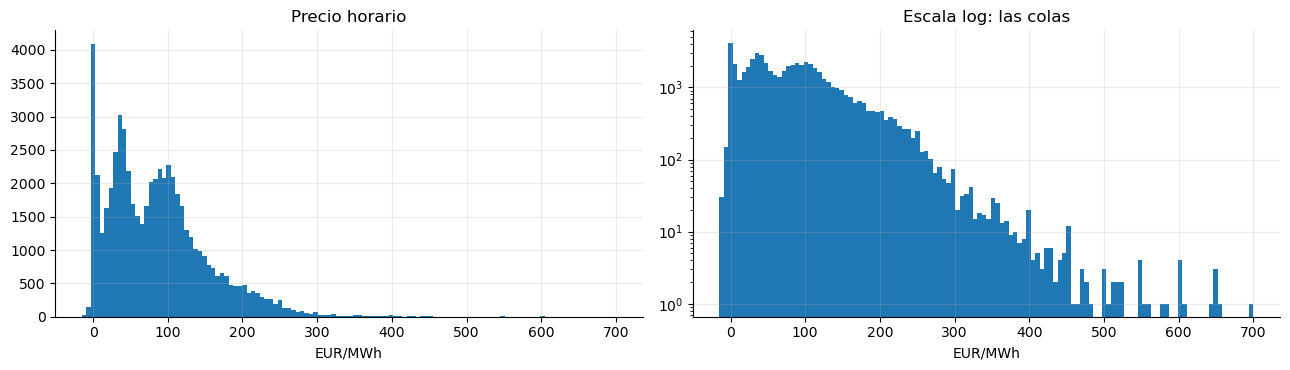

rango,negativo,cero,0-5,5-50,50-100,100-200,>200
anio,,,,,,,
2020,0,0,53,8023,707,0,0
2021,0,0,195,1267,3673,2348,1276
2022,0,3,110,186,863,5068,2529
2023,0,109,417,1208,3391,3626,8
2024,247,537,858,1979,2901,2261,0
2025,555,245,660,2048,2710,2492,25
2026,665,214,654,1147,1387,1592,52


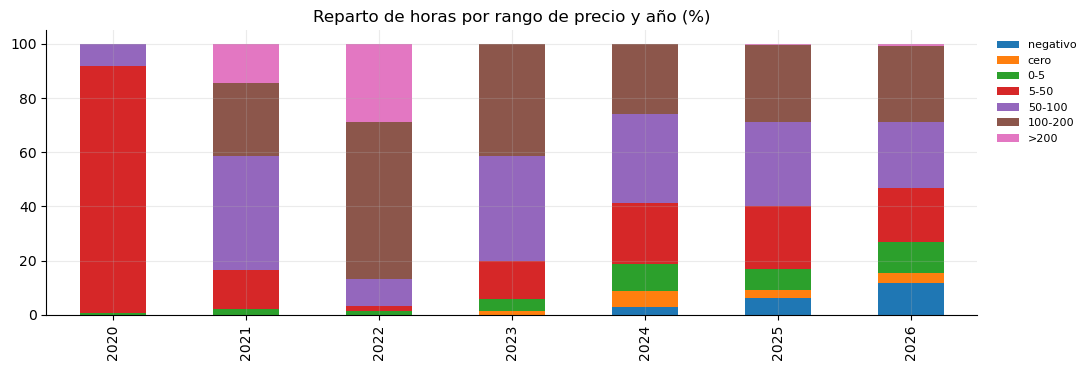

In [35]:
if SPOT:
    print(f"Asimetría: {P['precio'].skew():.2f} · Curtosis: {P['precio'].kurtosis():.2f}")
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
    axes[0].hist(P["precio"].dropna(), bins=120)
    axes[0].set_title("Precio horario"); axes[0].set_xlabel("EUR/MWh")
    axes[1].hist(P["precio"].dropna(), bins=120); axes[1].set_yscale("log")
    axes[1].set_title("Escala log: las colas"); axes[1].set_xlabel("EUR/MWh")
    plt.tight_layout(); plt.show()

    bins = [-np.inf, 0, 0.001, 5, 50, 100, 200, np.inf]
    etq = ["negativo", "cero", "0-5", "5-50", "50-100", "100-200", ">200"]
    P["rango"] = pd.cut(P["precio"], bins=bins, labels=etq, right=False)
    t = pd.crosstab(P["anio"], P["rango"])
    display(t)
    (t.div(t.sum(axis=1), axis=0) * 100).plot(kind="bar", stacked=True, figsize=(11, 3.8),
        title="Reparto de horas por rango de precio y año (%)")
    plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=8)
    plt.xlabel(""); plt.tight_layout(); plt.show()

## F.3 · Perfil horario por año — la curva pato del precio

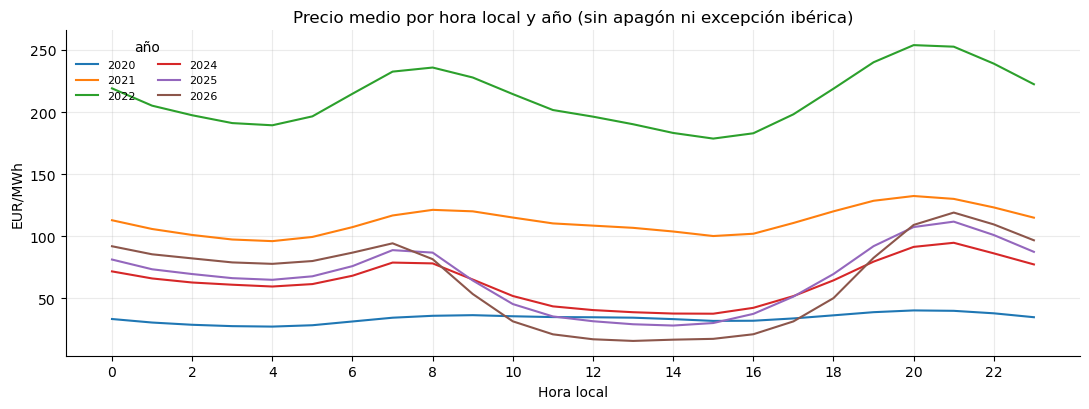

,amplitud_EUR,hora_del_mínimo
anio,,
2020,13.0,4
2021,36.3,4
2022,75.2,15
2024,57.1,15
2025,83.6,14
2026,103.3,13


Si la hora del mínimo se desplaza al mediodía y la amplitud crece, la estructura horaria NO es estacionaria: argumento para ponderar años recientes o incluir la capacidad FV instalada como regresor (crece de 8.659 a 54.668 MW en el período).


In [36]:
if SPOT:
    perfil = P[P["regimen"] == "normal"].pivot_table(index="hora", columns="anio",
                                                     values="precio", aggfunc="mean")
    ax = perfil.plot(figsize=(11, 4.2),
        title="Precio medio por hora local y año (sin apagón ni excepción ibérica)")
    ax.set_xlabel("Hora local"); ax.set_ylabel("EUR/MWh"); ax.set_xticks(range(0, 24, 2))
    ax.legend(title="año", frameon=False, ncol=2, fontsize=8)
    plt.tight_layout(); plt.show()
    display(pd.concat([(perfil.max() - perfil.min()).round(1).rename("amplitud_EUR"),
                       perfil.idxmin().rename("hora_del_mínimo")], axis=1))
    print("Si la hora del mínimo se desplaza al mediodía y la amplitud crece, la estructura "
          "horaria NO es estacionaria: argumento para ponderar años recientes o incluir la "
          "capacidad FV instalada como regresor (crece de 8.659 a 54.668 MW en el período).")

## F.4 · Regímenes

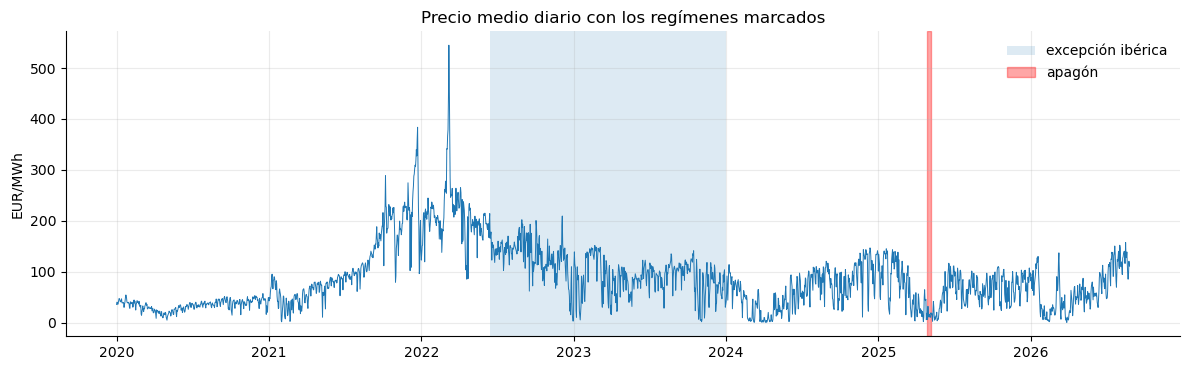

,count,mean,std,min,5%,50%,95%,max
regimen,,,,,,,,
apagon,216.0,14.19,21.80,-10.0,-4.00,4.30,56.54,117.01
excepcion_iberica,13558.0,102.63,47.82,0.0,6.74,105.00,176.00,300.00
normal,44515.0,81.06,71.48,-15.0,0.00,62.95,224.09,700.00


In [37]:
if SPOT:
    diario = P.groupby("dia")["precio"].mean()
    fig, ax = plt.subplots(figsize=(12, 3.8))
    ax.plot(pd.to_datetime(diario.index), diario.values, lw=0.7)
    ax.axvspan(EXCEPCION[0].tz_localize(None), EXCEPCION[1].tz_localize(None),
               alpha=0.15, label="excepción ibérica")
    ax.axvspan(APAGON[0].tz_localize(None), APAGON[1].tz_localize(None),
               color="red", alpha=0.35, label="apagón")
    ax.set_ylabel("EUR/MWh"); ax.set_title("Precio medio diario con los regímenes marcados")
    ax.legend(frameon=False); plt.tight_layout(); plt.show()
    display(P.groupby("regimen")["precio"].describe(percentiles=[.05, .5, .95]).round(2))

## F.5 · Persistencia: la vara contra la que se mide todo

**Consecuencia.** Un modelo con features exógenas que no supere claramente a la persistencia
D−1 no aporta nada. Esta celda fija esa referencia con un número, y es la justificación teórica
de `F11_baselines.ipynb`.

Autocorrelación del precio horario:
  D-1 (24h)    r = 0.9108
  D-2 (48h)    r = 0.8573
  D-7 (168h)   r = 0.8181

A nivel de media diaria:
  D-1  r = 0.9407
  D-2  r = 0.8870
  D-7  r = 0.8294


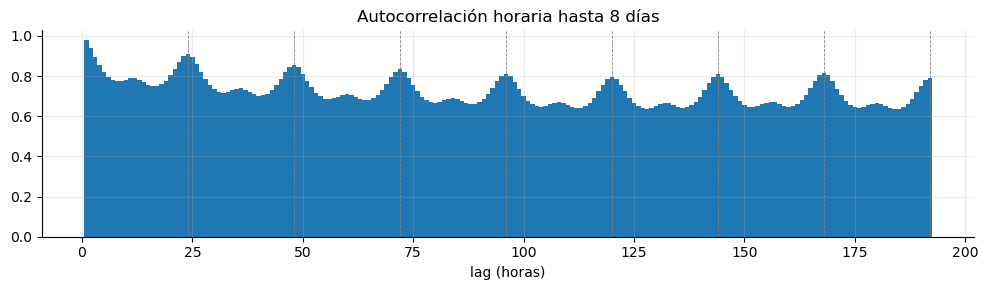

In [38]:
if SPOT:
    s = P.set_index("ts_utc")["precio"].asfreq("h")
    print("Autocorrelación del precio horario:")
    for etq_, k in {"D-1 (24h)": 24, "D-2 (48h)": 48, "D-7 (168h)": 168}.items():
        print(f"  {etq_:12s} r = {s.corr(s.shift(k)):.4f}")
    d = P.groupby("dia")["precio"].mean(); d.index = pd.to_datetime(d.index)
    print("\nA nivel de media diaria:")
    for etq_, k in {"D-1": 1, "D-2": 2, "D-7": 7}.items():
        print(f"  {etq_:4s} r = {d.corr(d.shift(k)):.4f}")

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.bar(range(1, 193), [s.corr(s.shift(k)) for k in range(1, 193)], width=1.0)
    for k in range(24, 193, 24):
        ax.axvline(k, color="grey", lw=0.6, ls="--")
    ax.set_title("Autocorrelación horaria hasta 8 días"); ax.set_xlabel("lag (horas)")
    plt.tight_layout(); plt.show()

## F.6 · Diferencial diario: el techo del BESS

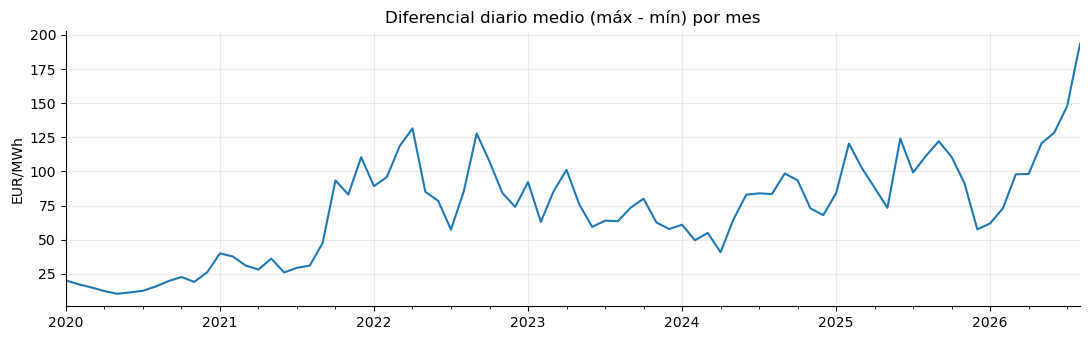

,min_del_año,max_del_año,diferencial_medio,dias_con_min_negativo
dia,,,,
2020,1.0,68.9,16.9,0
2021,0.0,409.0,49.6,0
2022,0.0,700.0,94.4,0
2023,0.0,220.0,73.3,0
2024,-2.0,193.0,71.3,46
2025,-15.0,240.0,98.4,89
2026,-9.8,255.2,114.0,108


In [39]:
if SPOT:
    sp = P.groupby("dia")["precio"].agg(["min", "max", "mean"]).dropna()
    sp.index = pd.to_datetime(sp.index); sp["diferencial"] = sp["max"] - sp["min"]
    ax = sp["diferencial"].resample("MS").mean().plot(figsize=(11, 3.5),
        title="Diferencial diario medio (máx - mín) por mes")
    ax.set_ylabel("EUR/MWh"); ax.set_xlabel(""); plt.tight_layout(); plt.show()
    display(sp.groupby(sp.index.year).agg(
        min_del_año=("min", "min"), max_del_año=("max", "max"),
        diferencial_medio=("diferencial", "mean"),
        dias_con_min_negativo=("min", lambda x: (x < 0).sum())).round(1))

## F.7 · Contraste de las tres fuentes españolas

**Contexto.** La base guarda el precio español por ESIOS, ENTSO-E y OMIE. Las tres medias
coinciden casi al céntimo (85,84 / 85,84 / 85,85), lo que apunta a que son intercambiables —
pero una media igual no garantiza que no difieran hora a hora.

**Consecuencia.** Si son equivalentes, se elige una, se documenta la elección y se cierra el
asunto para train y para test. Si no lo son, la elección del target es una decisión con
consecuencias y hay que argumentarla.

In [40]:
if len(ES_FUENTES) > 1:
    comp = df[list(ES_FUENTES.values())].dropna()
    print(f"Horas con las {len(ES_FUENTES)} fuentes presentes: {len(comp):,}")
    display(comp.corr().round(8))
    base_col = ES_FUENTES.get("es_omie", list(ES_FUENTES.values())[0])
    for nombre, c in ES_FUENTES.items():
        if c == base_col:
            continue
        dif = comp[c] - comp[base_col]
        print(f"{nombre:12s} dif. media {dif.mean():+.5f} · máx abs {dif.abs().max():.3f} · "
              f"horas con |dif| > 0,01: {(dif.abs() > 0.01).sum():,}")
    print("\nCobertura (nulos) de cada fuente -- criterio de desempate si son equivalentes:")
    display(df[list(ES_FUENTES.values())].isna().sum().rename("nulos").to_frame())
else:
    registrar("F.7: menos de dos fuentes españolas de precio")

Horas con las 3 fuentes presentes: 58,288


,spot_es_omie,spot_es_esios,spot_es_entsoe
spot_es_omie,1.0,1.0,1.0
spot_es_esios,1.0,1.0,1.0
spot_es_entsoe,1.0,1.0,1.0


es_esios     dif. media +0.00000 · máx abs 0.000 · horas con |dif| > 0,01: 0
es_entsoe    dif. media -0.00002 · máx abs 0.010 · horas con |dif| > 0,01: 85

Cobertura (nulos) de cada fuente -- criterio de desempate si son equivalentes:


,nulos
spot_es_omie,30
spot_es_esios,6
spot_es_entsoe,7


---
# G · Qué mueve el precio, con la etiqueta de fuga pegada

**Decisión de método:** toda tabla de correlaciones lleva una columna `disponible_12h`
**obligatoria**. Sin ella, la tabla no se copia a la memoria.

In [41]:
ETIQUETAS = [
    ("fc_", "SIN FUGA"), ("ent_fc_", "SIN FUGA"), ("forecast_", "SIN FUGA"),
    ("ecmwf_", "SIN FUGA"),
    ("tp_", "CON DESFASE (D-2)"), ("commodities_", "CON DESFASE (D-2)"),
    ("era5_", "CON FUGA (reanálisis)"),
    ("entsoe_", "CON FUGA (real)"), ("esios_gen_", "CON FUGA (real)"),
    ("load_inter_", "CON FUGA (real)"), ("gen_", "CON FUGA (real)"),
    ("ent_li_", "CON FUGA (real)"), ("pdbc_", "CON FUGA (circular)"),
    ("calc_", "CON FUGA (deriva de reales)"),
    ("cap_disp_", "CONDICIONAL (D-01)"), ("cap_inst_", "SIN FUGA (cambia despacio)"),
    ("spot_", "TARGET / vecinos CON FUGA"),
]

def etiqueta(col):
    for pref, val in ETIQUETAS:
        if col.startswith(pref):
            return val
    return "revisar"

if SPOT:
    num = df.select_dtypes(include=[np.number]).columns
    normal = df[df["regimen"] == "normal"]
    corr = normal[list(num)].corr()[SPOT].drop(SPOT, errors="ignore").rename("r").to_frame()
    corr["disponible_12h"] = [etiqueta(c) for c in corr.index]
    corr = corr.reindex(corr["r"].abs().sort_values(ascending=False).index)
    display(corr.head(25).round(4))

    sin_fuga = corr[corr["disponible_12h"].str.startswith(("SIN FUGA", "CON DESFASE"))]
    print("\nSólo lo que existe a las 12:00 de D:")
    display(sin_fuga.head(15).round(4))
    if len(sin_fuga):
        print(f"\nMejor |r| SIN fuga: {sin_fuga['r'].abs().max():.4f}")
        print(f"Mejor |r| CON fuga: {corr['r'].abs().max():.4f}")
        print("La diferencia entre ambas mide, en un número, cuánto cuesta la restricción "
              "de producción. Es un párrafo que la memoria necesita.")

,r,disponible_12h
spot_es_esios,1.0000,TARGET / vecinos CON FUGA
spot_es_entsoe,1.0000,TARGET / vecinos CON FUGA
spot_pt_omie,0.9979,TARGET / vecinos CON FUGA
spot_pt_entsoe,0.9979,TARGET / vecinos CON FUGA
commodities_gas_mibgas,0.8803,CON DESFASE (D-2)
spot_fr_entsoe,0.8720,TARGET / vecinos CON FUGA
commodities_gas_ttf_m1,0.8646,CON DESFASE (D-2)
spot_ch_entsoe,0.8297,TARGET / vecinos CON FUGA
spot_it_nord_entsoe,0.8249,TARGET / vecinos CON FUGA
spot_be_entsoe,0.8109,TARGET / vecinos CON FUGA



Sólo lo que existe a las 12:00 de D:


,r,disponible_12h
commodities_gas_mibgas,0.8803,CON DESFASE (D-2)
commodities_gas_ttf_m1,0.8646,CON DESFASE (D-2)
commodities_co2_eua_dec,0.5281,CON DESFASE (D-2)
forecast_demanda_residual_prev_mw,0.4391,SIN FUGA
cap_inst_waste_renewable_mw,0.4170,SIN FUGA (cambia despacio)
cap_inst_battery_hybrid_mw,0.3480,SIN FUGA (cambia despacio)
cap_inst_solar_pv_hybrid_mw,0.3388,SIN FUGA (cambia despacio)
forecast_gen_solar_pv_prev_mw,-0.2775,SIN FUGA
cap_inst_wind_hybrid_mw,0.2721,SIN FUGA (cambia despacio)
cap_inst_coal_mw,-0.2378,SIN FUGA (cambia despacio)



Mejor |r| SIN fuga: 0.8803
Mejor |r| CON fuga: 1.0000
La diferencia entre ambas mide, en un número, cuánto cuesta la restricción de producción. Es un párrafo que la memoria necesita.


## G.1 · Precio frente al gas, por régimen

,spot_es_omie,commodities_gas_ttf_m1,ratio
regimen,,,
apagon,12.17,32.87,0.36
excepcion_iberica,113.80,48.91,1.74
normal,81.12,33.60,2.58


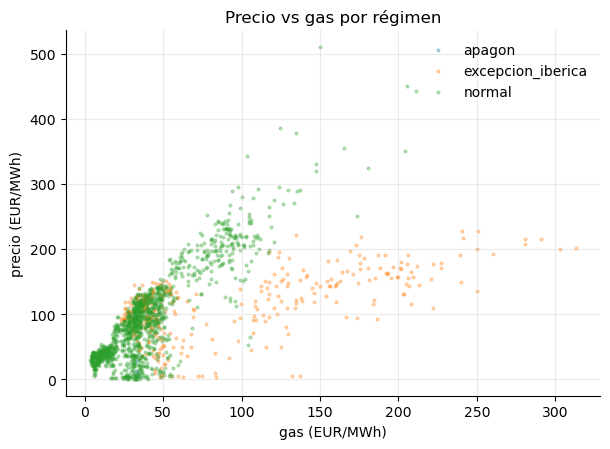

In [42]:
if SPOT and GAS:
    d = df[["ts_utc", "mes_p", "regimen", SPOT, GAS]].dropna().copy()
    d["ratio"] = d[SPOT] / d[GAS].replace(0, np.nan)
    display(d.groupby("regimen")[[SPOT, GAS, "ratio"]].median().round(2))
    fig, ax = plt.subplots(figsize=(6.2, 4.6))
    for r, sub in d.groupby("regimen"):
        ax.scatter(sub[GAS], sub[SPOT], s=4, alpha=0.3, label=r)
    ax.set_xlabel("gas (EUR/MWh)"); ax.set_ylabel("precio (EUR/MWh)")
    ax.set_title("Precio vs gas por régimen"); ax.legend(frameon=False)
    plt.tight_layout(); plt.show()
elif SPOT:
    registrar("G.1: sin columna de gas (ni trayport ni commodities)")

---
# H · La calidad de lo que sí podemos usar

**Contexto.** Las features sin fuga son **previsiones**, y una previsión trae su propio error.
Si la previsión de eólica se equivoca 1.500 MW de media, el modelo hereda ese error entero:
ningún algoritmo recupera información que la entrada no tiene.

Ahora se puede hacer mejor que en la v1, porque hay **dos previsiones independientes** del mismo
fenómeno: REE (`forecast`) y ENTSO-E (`entsoe_forecast_da`). La discrepancia entre ellas es una
medida directa de la incertidumbre irreducible de la entrada.

In [43]:
PARES = [
    ("demanda",  FC_DEM, DEM),
    ("eólica",   FC_EOL, EOL),
    ("solar FV", FC_FV,  FV),
]
filas = []
for etq_, cp, cr in PARES:
    if cp is None or cr is None:
        registrar(f"H.1 {etq_}: prev={cp} real={cr}")
        continue
    d = df[[cp, cr]].dropna()
    err = d[cp] - d[cr]
    filas.append({"variable": etq_, "n": len(d), "MAE_MW": err.abs().mean(),
                  "sesgo_MW": err.mean(),
                  "MAPE_%": (err.abs() / d[cr].replace(0, np.nan)).mean() * 100,
                  "corr": d[cp].corr(d[cr])})
if filas:
    display(pd.DataFrame(filas).set_index("variable").round(2))
    print("El sesgo importa tanto como el MAE: un sesgo sistemático se corrige antes de entrar "
          "al modelo; el ruido no.")

,n,MAE_MW,sesgo_MW,MAPE_%,corr
variable,,,,,
demanda,58277,256.85,0.76,0.95,0.99
eólica,58283,771.70,128.52,15.84,0.95
solar FV,58283,547.36,197.82,65.21,0.98


El sesgo importa tanto como el MAE: un sesgo sistemático se corrige antes de entrar al modelo; el ruido no.


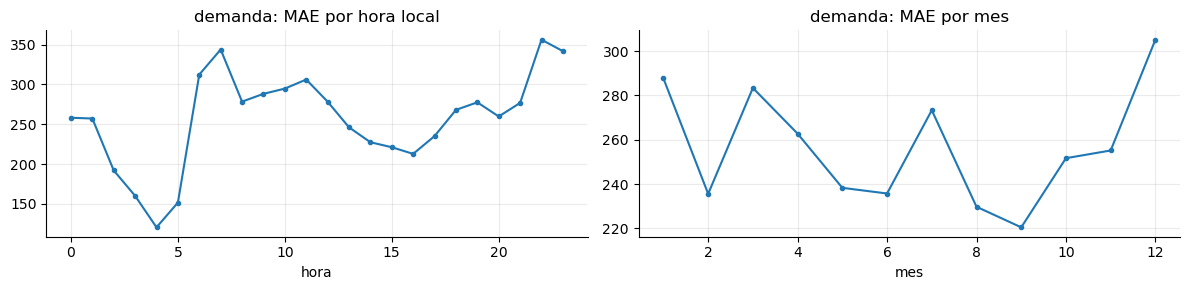

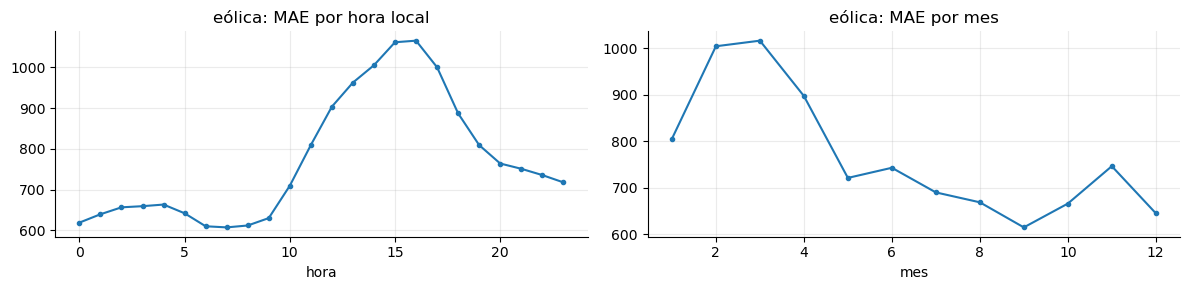

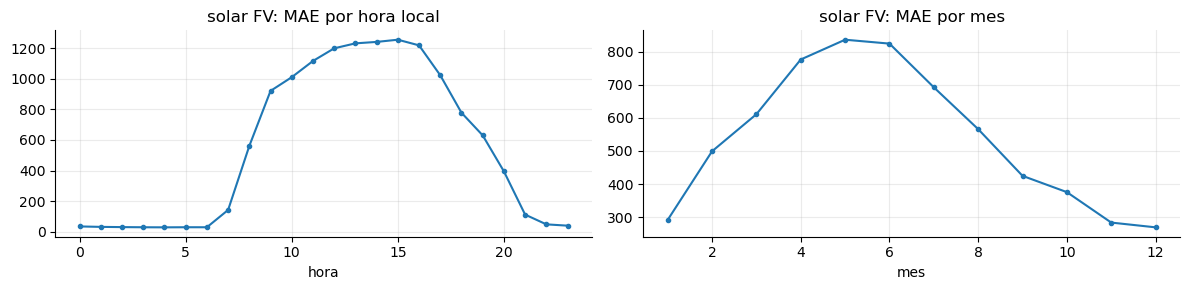

Si el MAE de la solar se dispara en las horas centrales y en primavera, es exactamente donde el precio es más difícil: explica de antemano dónde va a fallar el modelo.


In [44]:
# Dónde falla la previsión: por hora local y por mes.
for etq_, cp, cr in PARES:
    if cp is None or cr is None:
        continue
    d = df[["hora", "mes_p", cp, cr]].dropna().copy()
    d["err"] = (d[cp] - d[cr]).abs()
    d["mes"] = d["mes_p"].dt.month
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    d.groupby("hora")["err"].mean().plot(ax=axes[0], marker="o", ms=3)
    axes[0].set_title(f"{etq_}: MAE por hora local")
    d.groupby("mes")["err"].mean().plot(ax=axes[1], marker="o", ms=3)
    axes[1].set_title(f"{etq_}: MAE por mes")
    plt.tight_layout(); plt.show()
print("Si el MAE de la solar se dispara en las horas centrales y en primavera, es exactamente "
      "donde el precio es más difícil: explica de antemano dónde va a fallar el modelo.")

## H.1b · REE frente a ENTSO-E: dos previsiones del mismo fenómeno

**Contexto.** Las medias difieren (solar: 4.186 MW en REE frente a 4.487 en ENTSO-E), así que no
son copias. **Consecuencia:** si dos organismos serios difieren sistemáticamente en su previsión
de solar, esa discrepancia es una cota inferior de la incertidumbre que el modelo va a heredar,
y merece la pena probar si su media o su diferencia funcionan mejor que cualquiera por separado.

In [45]:
ENT_PARES = [("demanda", FC_DEM, pick(df, "ent_fc_load_forecast_mw", "load_forecast_mw")),
             ("eólica", FC_EOL, pick(df, "ent_fc_wind_forecast_mw", "wind_forecast_mw")),
             ("solar", FC_FV, pick(df, "ent_fc_solar_forecast_mw", "solar_forecast_mw"))]
filas = []
for etq_, a, b in ENT_PARES:
    if a is None or b is None:
        continue
    d = df[[a, b]].dropna()
    dif = d[a] - d[b]
    filas.append({"variable": etq_, "n": len(d), "REE media": d[a].mean(),
                  "ENTSO-E media": d[b].mean(), "dif. media": dif.mean(),
                  "dif. |media|": dif.abs().mean(), "corr": d[a].corr(d[b])})
if filas:
    display(pd.DataFrame(filas).set_index("variable").round(2))
else:
    registrar("H.1b: falta entsoe_forecast_da en el bronce")

OMITIDO -- H.1b: falta entsoe_forecast_da en el bronce


## H.2 · ECMWF: por qué esta ablación no se puede hacer todavía

**Lo que decía la v1.** Comparar ECMWF (previsión) contra ERA5 (reanálisis) para medir cuánto
vale la "meteorología perfecta" y poder reportar los resultados con meteo como cota superior.

**Por qué no se sostiene.** `ecmwf_forecast_agg` tiene **168 filas**: 21 días en pasos de 3 h.
Es una ventana móvil para inferencia, no un histórico. Con tres semanas se puede dar un orden
de magnitud del error, no una ablación.

**Consecuencia para la memoria, que hay que escribir explícitamente.** Sin previsión
meteorológica histórica no se puede entrenar con la meteo que existirá en producción: sólo con
ERA5, que es el tiempo que realmente ocurrió. **Todo resultado que use meteorología es por tanto
una cota superior optimista**, no el rendimiento esperado. Es una limitación estructural del
dato, no un fallo del EDA — y es mucho mejor declararla nosotros que oírla en la defensa.

**La vía que sigue abierta.** La tabla tiene `tensor_path` y `tensor_index` apuntando a ficheros
`.npy` por `run_date` en el VPS. Si esos ficheros están guardados desde hace meses, el histórico
de previsión **existe fuera de la base** y la ablación vuelve a ser posible. Un `ls` lo resuelve:

```bash
ls /home/ubuntu/scripts/ingesta/tensors/ecmwf_forecast/ | head -20
ls /home/ubuntu/scripts/ingesta/tensors/ecmwf_forecast/ | wc -l
```

In [46]:
ec_cols = [c for c in df.columns if c.startswith("ecmwf_")]
if not ec_cols:
    registrar("H.2: ecmwf_forecast_agg no está en el bronce (168 filas: ventana móvil)")
else:
    d = df[["ts_utc"] + ec_cols].dropna(how="all", subset=ec_cols)
    print(f"Filas de ECMWF en el unificado: {len(d):,} · "
          f"rango {d['ts_utc'].min()} -> {d['ts_utc'].max()}")
    print("Con esta cobertura sólo cabe un orden de magnitud del error, no una ablación.")
    filas = []
    for c in ec_cols:
        gemela = pick(df, c.replace("ecmwf_", "era5_"))
        if gemela is None:
            continue
        dd = df[[c, gemela]].dropna()
        if len(dd) < 30:
            continue
        err = dd[c] - dd[gemela]
        filas.append({"variable": gemela, "n": len(dd), "MAE": err.abs().mean(),
                      "sesgo": err.mean(), "corr": dd[c].corr(dd[gemela])})
    if filas:
        display(pd.DataFrame(filas).set_index("variable").round(3))
        print("\nOrientativo: pocas semanas de solape. NO es la ablación de meteo perfecta.")

OMITIDO -- H.2: ecmwf_forecast_agg no está en el bronce (168 filas: ventana móvil)


## H.3 · D-01: test directo sobre la potencia disponible

**Contexto.** `esios_capacity_available` se publica a las 4:30 de D con datos de D+1, así que
sería feature legítima. Pero la ingesta guarda **una fila creada a las 21:05 del propio día**,
o sea el valor conocido *a posteriori*. La fuga se concentraría en las **paradas imprevistas**:
justo los días de precio extremo.

**Lo que ahora se puede comprobar directamente.** La tabla guarda 24 filas por día. Si las 24
son idénticas, es un valor diario único y el horizonte se perdió; si varían dentro del día, la
tabla conserva algo de estructura horaria y la conclusión cambia. Antes esto se testeaba de
forma indirecta con correlaciones; ahora se cuenta.

In [47]:
cap_cols = [c for c in df.columns if c.startswith("cap_disp_")]
if not cap_cols:
    registrar("H.3: faltan las columnas cap_disp_*")
else:
    d = df[["dia"] + cap_cols].dropna(how="all", subset=cap_cols)
    variacion = d.groupby("dia")[cap_cols].nunique()
    resumen = pd.DataFrame({
        "días": len(variacion),
        "días con valor único": (variacion == 1).sum(),
        "días con más de un valor": (variacion > 1).sum(),
    })
    display(resumen.T)
    pct = (variacion > 1).sum().sum() / max(variacion.size, 1) * 100
    print(f"\n{pct:.1f}% de las combinaciones (día × tecnología) varían dentro del día.")
    print("Cerca de 0% -> es un dato diario replicado 24 veces: el horizonte se perdió y D-01 "
          "queda confirmado. Lejos de 0% -> la tabla sí tiene estructura horaria y hay que "
          "replantear el diagnóstico.")

    # Indicio adicional: ¿conoce el valor del propio día mejor que el del anterior?
    reales = {"cap_disp_ccgt_mw": CCGT,
              "cap_disp_nuclear_mw": pick(df, "entsoe_nuclear_mw", "gen_ree_gnuclear"),
              "cap_disp_hydro_mw": pick(df, "calc_hydro_dispatch_mw", "gen_c_ghydrodispatch")}
    filas = []
    for cap, real in reales.items():
        c = pick(df, cap)
        if c is None or real is None:
            continue
        g = df.groupby("dia").agg(cap=(c, "max"), real=(real, "mean")).dropna()
        filas.append({"capacidad": cap, "corr con real del MISMO día": g["cap"].corr(g["real"]),
                      "corr con el día ANTERIOR": g["cap"].corr(g["real"].shift(1)),
                      "días": len(g)})
    if filas:
        display(pd.DataFrame(filas).set_index("capacidad").round(4))

,cap_disp_hydro_mw,cap_disp_pump_mw,cap_disp_nuclear_mw,cap_disp_coal_antracita_mw,cap_disp_ccgt_mw,cap_disp_fuel_mw
días,2430,2430,2430,2430,2430,2430
días con valor único,2430,2430,2430,2430,2430,2430
días con más de un valor,0,0,0,0,0,0



0.0% de las combinaciones (día × tecnología) varían dentro del día.
Cerca de 0% -> es un dato diario replicado 24 veces: el horizonte se perdió y D-01 queda confirmado. Lejos de 0% -> la tabla sí tiene estructura horaria y hay que replantear el diagnóstico.


,corr con real del MISMO día,corr con el día ANTERIOR,días
capacidad,,,
cap_disp_ccgt_mw,0.1216,0.1282,2430
cap_disp_hydro_mw,0.5228,0.5395,2429


---
# I · PDBC: ¿aporta algo con lag, o sólo circularidad?

**Contexto.** El PDBC de D+1 sale de la misma casación que el precio: contemporáneo es circular
por construcción. Pero con lag sí es información válida, y puede ser mejor predictor que la
generación real porque refleja lo que el sistema *planificó*.

**Aviso sobre el signo, de la radiografía:** `pumping_cons_mw` es **negativo** en esta tabla (de
−4.690 a 0), al revés que en ENTSO-E, que lo guarda positivo. Mezclarlas sin mirar el signo
produce un error silencioso. Es el mismo problema de convención del hallazgo B.1, con otra cara.

In [48]:
pdbc_cols = [c for c in df.columns if c.startswith("pdbc_")]
if not (SPOT and pdbc_cols):
    registrar("I: falta esios_pdbc_gen en el bronce o falta el precio")
else:
    s = df.set_index("ts_utc")[SPOT].asfreq("h")
    filas = []
    for c in pdbc_cols:
        x = df.set_index("ts_utc")[c].asfreq("h")
        filas.append({"columna": c,
                      "contemporánea (CIRCULAR)": s.corr(x),
                      "lag D-1": s.corr(x.shift(24)), "lag D-7": s.corr(x.shift(168))})
    r = pd.DataFrame(filas).set_index("columna").round(4)
    display(r.reindex(r["lag D-1"].abs().sort_values(ascending=False).index))
    print("\nLa primera columna se muestra sólo para dejar constancia de la magnitud de la "
          "circularidad. No es una feature candidata.")

OMITIDO -- I: falta esios_pdbc_gen en el bronce o falta el precio


---
# J · El precio español entre sus vecinos

**Lo que cambia respecto de la v1.** Ya no hace falta el dataset externo de Ember: la base trae
**doce zonas de precio** en la propia tabla `spot_price`. El análisis de congestión y el
contexto europeo salen de datos propios, que además cubren exactamente el mismo período.

**La advertencia, otra vez y en negrita:** todas las zonas SDAC se casan **a la vez a las
12:00** y se publican hacia las 12:45. El precio francés de D+1 **no existe** cuando hay que
predecir el español de D+1. Este bloque explica, no predice. Sólo el precio de D es utilizable.

**Cómo se mide la congestión sin un dato de congestión.** En un mercado acoplado, si la
interconexión no está saturada los precios convergen. Diferencia por debajo de un umbral
pequeño = hora acoplada; por encima = congestión, y el signo da el sentido.

In [49]:
if not (SPOT and VECINOS):
    registrar("J: falta el precio español o las zonas vecinas")
else:
    corr_v = df[[SPOT] + list(VECINOS.values())].corr()[SPOT].drop(SPOT).sort_values(ascending=False)
    corr_v.index = [k for k, v in VECINOS.items() if v in corr_v.index] or corr_v.index
    display(corr_v.round(4).rename("correlación con ES").to_frame())
    print("Correlaciones altas y TODAS con fuga: es el ejemplo de manual de por qué una "
          "correlación fuerte no autoriza una feature.")

,correlación con ES
Portugal,0.9965
Portugal (ENTSO-E),0.9965
Francia,0.7050
Alemania-Lux,0.6792
Italia norte,0.6763
Suiza,0.6664
Bélgica,0.6504
Países Bajos,0.6470
Austria,0.6264
Polonia,0.6166


Correlaciones altas y TODAS con fuga: es el ejemplo de manual de por qué una correlación fuerte no autoriza una feature.



Portugal:


estado,ES más barato,ES más caro,acoplado,|dif| media
anio,,,,
2020,2.2,1.9,95.9,0.12
2021,1.3,1.3,97.4,0.20
2022,2.4,0.5,97.1,0.53
2023,4.6,0.7,94.7,1.34
2024,4.6,1.3,94.1,0.74
2025,9.5,0.9,89.5,1.29
2026,9.4,6.1,84.5,1.90


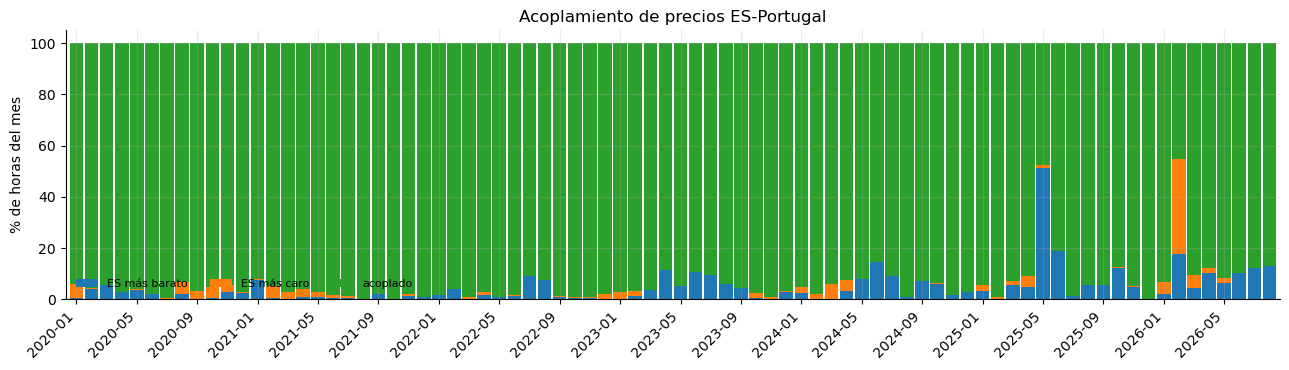


Francia:


estado,ES más barato,ES más caro,acoplado,|dif| media
anio,,,,
2020,19.9,40.7,39.3,5.85
2021,22.9,42.3,34.8,20.23
2022,63.4,9.9,26.7,115.19
2023,38.7,28.5,32.8,26.32
2024,27.8,39.5,32.7,22.33
2025,28.3,35.3,36.4,20.29
2026,38.9,31.8,29.2,27.72


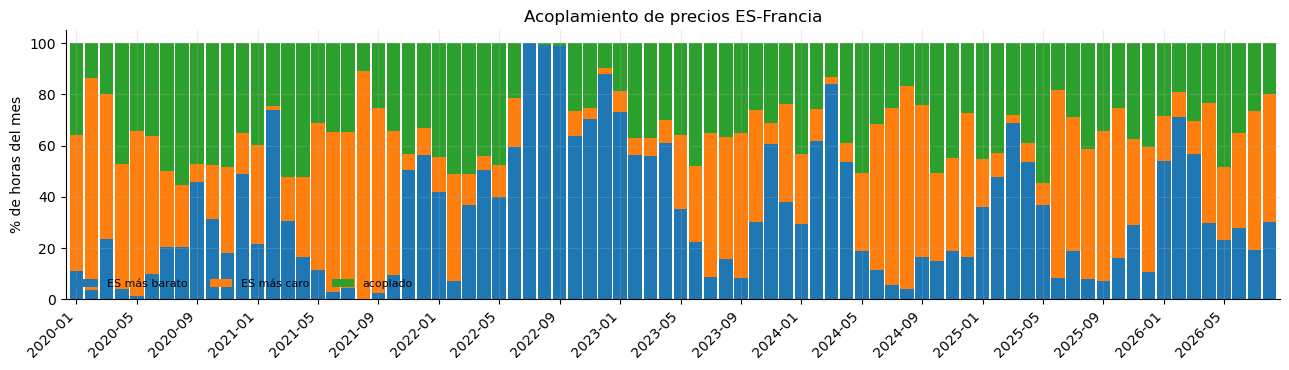


Con PORTUGAL: si el % acoplado es alto y estable, tratar el perímetro peninsular como una sola zona está justificado con datos -- supuesto que el TFM ya asume sin haberlo verificado. Con FRANCIA: cuanta más congestión, más independiente es el precio español.


In [50]:
UMBRAL = 0.01   # EUR/MWh: por debajo, precios convergidos

if SPOT and VECINOS:
    for pais in ["Portugal", "Francia"]:
        c = VECINOS.get(pais)
        if c is None:
            continue
        d = df[["anio", "mes_p", SPOT, c]].dropna().copy()
        d["dif"] = d[SPOT] - d[c]
        d["estado"] = np.select(
            [d["dif"].abs() <= UMBRAL, d["dif"] > UMBRAL],
            ["acoplado", "ES más caro"], default="ES más barato")

        anual = pd.crosstab(d["anio"], d["estado"], normalize="index").mul(100).round(1)
        anual["|dif| media"] = d.groupby("anio")["dif"].apply(lambda s: s.abs().mean()).round(2)
        print(f"\n{pais}:")
        display(anual)

        mensual = pd.crosstab(d["mes_p"], d["estado"], normalize="index") * 100
        fig, ax = plt.subplots(figsize=(13, 3.8))
        mensual.plot(kind="bar", stacked=True, ax=ax, width=0.9)
        paso = max(1, len(mensual) // 20)
        ax.set_xticks(range(0, len(mensual), paso),
                      [str(i) for i in mensual.index[::paso]], rotation=45, ha="right")
        ax.set_ylabel("% de horas del mes"); ax.set_xlabel("")
        ax.set_title(f"Acoplamiento de precios ES-{pais}")
        ax.legend(frameon=False, ncol=3, fontsize=8, loc="lower left")
        plt.tight_layout(); plt.show()

    print("\nCon PORTUGAL: si el % acoplado es alto y estable, tratar el perímetro peninsular "
          "como una sola zona está justificado con datos -- supuesto que el TFM ya asume sin "
          "haberlo verificado. Con FRANCIA: cuanta más congestión, más independiente es el "
          "precio español.")

---
# N · Discontinuidades de ERA5

**Contexto.** Al exportar la tabla completa aparecieron dos cosas que el perfil de nulos del
bloque B no podía mostrar, porque una no deja nulos.

**N.1 — un mes entero sin ráfaga.** Los 240 nulos de `wind_gust10_mean` son exactamente junio de
2026 completo, del día 1 a las 00:00 al 30 a las 21:00, bloque continuo. Ninguna otra variable
falta en ese mes. Esto cierra el hallazgo B.2: la hipótesis de censura por viento bajo ya se
había descartado, y ahora se sabe que es **un fallo aislado de una ejecución**, reparable
reingiriendo el mes.

**N.2 — cambio de entorno de ingesta en enero de 2025.** El campo `tensor_path` apunta a
`/home/ubuntu/scripts/ingesta/tensors/era5/` hasta diciembre-2024 y a `\data\era5_tensors\`
(ruta de Windows) desde enero-2025, sin excepciones: **20 meses seguidos**. No es una reingesta
manual puntual, es que el pipeline cambió de máquina y sigue así.

**Por qué N.2 importa más que N.1.** Diecinueve de esos veinte meses están completos, así que el
cambio de entorno no causa nulos. Pero si cambió la malla, el recorte geográfico o la versión
del agregador, las series de 2025-2026 podrían tener un **sesgo** respecto a 2020-2024 que no se
ve mirando nulos — y ese tramo es justo el período de test. Es el mismo tipo de discontinuidad
que D-03 con el autoconsumo de REE, con la diferencia de que aquélla está documentada y ésta no.

**Cómo se comprueba.** `msl_mean` (presión a nivel del mar) es la variable más estable de todas
y la mejor para detectar un desplazamiento artificial: su media climatológica apenas cambia de
un año a otro. Si salta entre diciembre-2024 y enero-2025, hay cambio metodológico.

In [51]:
era5_cols = [c for c in df.columns if c.startswith("era5_")]
if not era5_cols:
    registrar("N: no hay columnas era5_ en el bronce")
else:
    CORTE = pd.Timestamp("2025-01-01", tz="UTC")
    e = df[["ts_utc", "mes_p", "anio"] + era5_cols].dropna(how="all", subset=era5_cols).copy()
    e["entorno"] = np.where(e["ts_utc"] >= CORTE, "desde 2025 (Windows)", "hasta 2024 (VPS)")
    e["mes"] = e["mes_p"].dt.month

    # Comparación controlada por estacionalidad: mismo mes del año a ambos lados del corte.
    filas = []
    for c in era5_cols:
        por_mes = e.pivot_table(index="mes", columns="entorno", values=c, aggfunc="mean")
        if por_mes.shape[1] < 2:
            continue
        dif = (por_mes.iloc[:, 0] - por_mes.iloc[:, 1])
        filas.append({"variable": c, "dif. media entre entornos": dif.mean(),
                      "dif. como % de la media": dif.mean() / e[c].mean() * 100,
                      "dif. máx en un mes": dif.abs().max()})
    if filas:
        r = pd.DataFrame(filas).set_index("variable").round(4)
        display(r.reindex(r["dif. como % de la media"].abs().sort_values(ascending=False).index))
        print("Comparación mes a mes del año, así la estacionalidad no contamina el contraste.\n"
              "Diferencias por debajo del ~0,5% son ruido climático entre años distintos.\n"
              "Una diferencia sistemática y del mismo signo en TODAS las variables sería la "
              "firma de un cambio de agregador, no del tiempo.")

,dif. media entre entornos,dif. como % de la media,dif. máx en un mes
variable,,,
era5_tp_mean,0.0124,16.5653,0.0729
era5_tcc_mean,0.0062,1.3183,0.1174
era5_wind100_mean,0.0501,0.9360,1.3570
era5_wind10_mean,0.0344,0.8900,0.9098
era5_wind_gust10_mean,0.0466,0.6610,1.6227
era5_ssrd_mean,0.5232,0.2641,17.9329
era5_t2m_mean,0.3335,0.1152,2.2706
era5_msl_mean,-105.9880,-0.1042,658.5855
era5_d2m_mean,0.2933,0.1035,1.4105


Comparación mes a mes del año, así la estacionalidad no contamina el contraste.
Diferencias por debajo del ~0,5% son ruido climático entre años distintos.
Una diferencia sistemática y del mismo signo en TODAS las variables sería la firma de un cambio de agregador, no del tiempo.


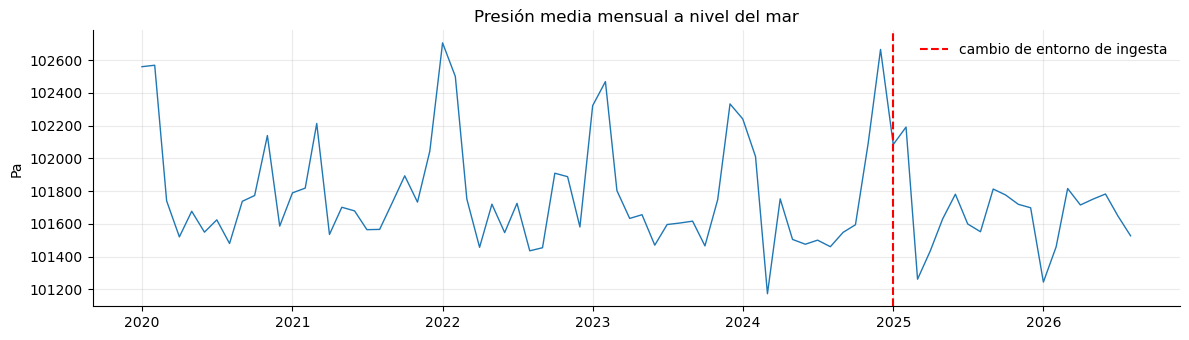

La presión es la variable más estable del conjunto: un escalón visible en la línea roja sería evidencia de cambio metodológico, no de meteorología.

Meses con nulos de ráfaga: 1


,pasos 3h sin dato
mes_p,
2026-06,240


Un único mes completo -> fallo de una ejecución concreta, no un patrón. Reparable reingiriendo ese mes.


In [52]:
if era5_cols:
    msl = pick(df, "era5_msl_mean")
    if msl:
        m = e.groupby("mes_p")[msl].mean()
        fig, ax = plt.subplots(figsize=(12, 3.5))
        ax.plot(m.index.to_timestamp(), m.values, lw=1)
        ax.axvline(CORTE.tz_localize(None), color="red", ls="--",
                   label="cambio de entorno de ingesta")
        ax.set_ylabel("Pa"); ax.set_title("Presión media mensual a nivel del mar")
        ax.legend(frameon=False); plt.tight_layout(); plt.show()
        print("La presión es la variable más estable del conjunto: un escalón visible en la "
              "línea roja sería evidencia de cambio metodológico, no de meteorología.")

    gust = pick(df, "era5_wind_gust10_mean")
    if gust:
        nulos_mes = e.groupby("mes_p")[gust].apply(lambda s: s.isna().sum())
        con_nulos = nulos_mes[nulos_mes > 0]
        print(f"\nMeses con nulos de ráfaga: {len(con_nulos)}")
        display(con_nulos.rename("pasos 3h sin dato").to_frame())
        print("Un único mes completo -> fallo de una ejecución concreta, no un patrón. "
              "Reparable reingiriendo ese mes.")

---
# K · Cierre: la tabla que se lleva el feature engineering

In [53]:
VEREDICTOS = pd.DataFrame([
    ("spot_price es_omie",        "TARGET",      "—",
     "Objetivo. Las tres fuentes ES son equivalentes (F.7): elegir una y cerrarlo."),
    ("spot_price vecinos (11)",   "CON FUGA",    "sólo el precio de D",
     "Casación SDAC simultánea a las 12:00. Correlación alta e inutilizable para D+1."),
    ("fc_* (forecast, 12 col.)",  "SIN FUGA",    "uso directo",
     "Publicadas antes de las 11:00 de D-1. `autoconsumo_estimado` marca el corte de D-03."),
    ("esios_forecast_da",         "SIN FUGA",    "sólo 4 columnas",
     "Las otras 10 duplican `forecast` hasta el decimal."),
    ("ent_fc_* (ENTSO-E)",        "SIN FUGA",    "contraste con REE",
     "Difiere de REE: la discrepancia mide la incertidumbre de la entrada (H.1b)."),
    ("ecmwf_forecast_agg",        "SIN FUGA",    "no usable todavía",
     "168 filas: ventana móvil. Sin histórico, la meteo da COTA SUPERIOR optimista (H.2)."),
    ("era5_*",                    "CON FUGA",    "sólo con lag o ablación",
     "Reanálisis. Además: discontinuidad de entorno en ene-2025 sin verificar (N.2)."),
    ("era5_wind_gust10_mean",     "CON FUGA",    "no interpolar linealmente",
     "Variable de pico. Junio-2026 entero sin dato: reingerir (N.1)."),
    ("generation / load_inter",   "CON FUGA",    "lag D-1 y D-7",
     "Consecuencia del precio, no predictor."),
    ("entsoe_pumping_gen_mw",     "CON FUGA",    "fillna(0) ANTES de agregar",
     "NaN = 'no hubo turbinación' (B.1). Sin esto la media diaria queda inflada."),
    ("pdbc_pumping_cons_mw",      "CON FUGA",    "OJO: signo negativo",
     "Al revés que en ENTSO-E. Mezclarlas sin mirar el signo es un error silencioso."),
    ("load_inter_entsoe_load",    "CON FUGA",    "9 ceros -> NaN o reparar",
     "Fallo de ingesta documentado en pipeline_log (72 reintentos fallidos). "
     "`ent_li_actual_load_mw` puede tener el dato bueno: reparar es mejor que imputar."),
    ("cap_disp_*",                "CONDICIONAL", "no usar hasta tener _fc",
     "D-01: valor creado a las 21:05 del propio día. Ver H.3."),
    ("cap_inst_* constantes (5)", "descartada",  "—",
     "pump, nuclear, ccgt, fuel y autoconsume_battery: varianza cero en 6 años (D-04)."),
    ("tp_* (trayport)",           "CON DESFASE", "usar D-2",
     "Mejor que commodities: curva forward, volumen y pct_agresor_compra desde 2020."),
], columns=["columna / familia", "veredicto", "tratamiento", "motivo (bloque)"])
VEREDICTOS

,columna / familia,veredicto,tratamiento,motivo (bloque)
0,spot_price es_omie,TARGET,—,Objetivo. Las tres fuentes ES son equivalentes...
1,spot_price vecinos (11),CON FUGA,sólo el precio de D,Casación SDAC simultánea a las 12:00. Correlac...
2,"fc_* (forecast, 12 col.)",SIN FUGA,uso directo,Publicadas antes de las 11:00 de D-1. `autocon...
3,esios_forecast_da,SIN FUGA,sólo 4 columnas,Las otras 10 duplican `forecast` hasta el deci...
4,ent_fc_* (ENTSO-E),SIN FUGA,contraste con REE,Difiere de REE: la discrepancia mide la incert...
5,ecmwf_forecast_agg,SIN FUGA,no usable todavía,"168 filas: ventana móvil. Sin histórico, la me..."
6,era5_*,CON FUGA,sólo con lag o ablación,Reanálisis. Además: discontinuidad de entorno ...
7,era5_wind_gust10_mean,CON FUGA,no interpolar linealmente,Variable de pico. Junio-2026 entero sin dato: ...
8,generation / load_inter,CON FUGA,lag D-1 y D-7,"Consecuencia del precio, no predictor."
9,entsoe_pumping_gen_mw,CON FUGA,fillna(0) ANTES de agregar,NaN = 'no hubo turbinación' (B.1). Sin esto la...


In [54]:
print("BLOQUES OMITIDOS EN ESTA CORRIDA")
print("=" * 62)
if OMITIDOS:
    for o in dict.fromkeys(OMITIDOS):
        print(" -", o)
    print("\nCada línea es una pregunta del EDA sin responder. O se resuelve la dependencia, "
          "o se declara como limitación en la memoria. Lo que no vale es dejarla en silencio.")
else:
    print("Ninguno: el notebook corrió completo.")

print()
for l in [
    "PRÓXIMOS PASOS",
    "=" * 62,
    "",
    "  1. Verificar las fechas de la excepción ibérica contra el BOE: hoy están puestas de",
    "     memoria en la constante EXCEPCION y condicionan F.4 y G.1.",
    "  2. Reingerir junio-2026 de ERA5 para cerrar N.1.",
    "  3. Comprobar el cambio de entorno de ene-2025 (N.2) antes de usar era5 en el test.",
    "  4. ls en el VPS sobre tensors/ecmwf_forecast/: si hay histórico, H.2 vuelve a ser",
    "     posible y la meteo deja de ser una cota superior.",
    "  5. Reparar los 9 ceros de entsoe_load con ent_li_actual_load_mw en vez de imputar.",
    "  6. Extraer esios_capacity_available_fc con clave (run_date, target_date): cierra D-01.",
]:
    print(l)

BLOQUES OMITIDOS EN ESTA CORRIDA
 - H.1b: falta entsoe_forecast_da en el bronce
 - H.2: ecmwf_forecast_agg no está en el bronce (168 filas: ventana móvil)
 - I: falta esios_pdbc_gen en el bronce o falta el precio

Cada línea es una pregunta del EDA sin responder. O se resuelve la dependencia, o se declara como limitación en la memoria. Lo que no vale es dejarla en silencio.

PRÓXIMOS PASOS

  1. Verificar las fechas de la excepción ibérica contra el BOE: hoy están puestas de
     memoria en la constante EXCEPCION y condicionan F.4 y G.1.
  2. Reingerir junio-2026 de ERA5 para cerrar N.1.
  3. Comprobar el cambio de entorno de ene-2025 (N.2) antes de usar era5 en el test.
  4. ls en el VPS sobre tensors/ecmwf_forecast/: si hay histórico, H.2 vuelve a ser
     posible y la meteo deja de ser una cota superior.
  5. Reparar los 9 ceros de entsoe_load con ent_li_actual_load_mw en vez de imputar.
  6. Extraer esios_capacity_available_fc con clave (run_date, target_date): cierra D-01.
